# Домашнее задание к занятию «Ансамблирование»

Выполнил: Ярослав Золотухин

## Импортируем данные

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.metrics import classification_report
from sklearn.svm import LinearSVC

data = pd.read_csv( 'heart.csv' )
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [45]:
# категориальные переменные
data_one_hot_encoding = pd.get_dummies( data, columns = [ 'Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope' ] )

X = data_one_hot_encoding.drop(columns=['HeartDisease'])
y = data_one_hot_encoding['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## DecisionTreeClassifier

In [46]:
model_tree = DecisionTreeClassifier(random_state=10).fit(X_train, y_train)
y_pred_tree = model_tree.predict(X_test)
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.71      0.82      0.76        77
           1       0.85      0.76      0.80       107

    accuracy                           0.78       184
   macro avg       0.78      0.79      0.78       184
weighted avg       0.79      0.78      0.78       184



## RandomForestClassifier

In [47]:
model_rand_forest = RandomForestClassifier(random_state=10).fit(X_train, y_train)
y_pred_rand_forest = model_rand_forest.predict(X_test)
print(classification_report(y_test, y_pred_rand_forest))

              precision    recall  f1-score   support

           0       0.84      0.87      0.85        77
           1       0.90      0.88      0.89       107

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.88      0.88      0.88       184



Модель случайного леса показала более лучшие результаты.

### Рисуем столбчатую диаграмму по важности признаков

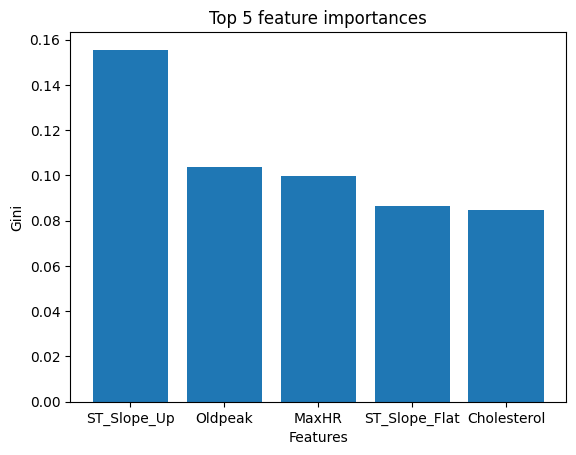

In [48]:
imp = pd.Series(model_rand_forest.feature_importances_)
imp.index = pd.Series(X_train.columns)
imp = imp.sort_values(ascending=False)

plt.title('Top 5 feature importances')
plt.xlabel('Features')
plt.ylabel('Gini')
plt.bar(imp.head().index, imp.head())
plt.show()

## Обучите бэггинг над моделью model_tree

In [49]:
from sklearn.ensemble import  BaggingClassifier

bagging = BaggingClassifier(model_tree,
                           n_estimators=10,
                           max_samples=0.5,
                           max_features=0.5,
                           random_state=10)

bagging.fit(X_train, y_train)
y_pred_bagging = bagging.predict(X_test)
print(classification_report(y_test, y_pred_bagging))

              precision    recall  f1-score   support

           0       0.74      0.88      0.80        77
           1       0.90      0.78      0.83       107

    accuracy                           0.82       184
   macro avg       0.82      0.83      0.82       184
weighted avg       0.83      0.82      0.82       184



## Стекинг

In [50]:
stacking = StackingClassifier(
    [
        ('DecisionTreeClassifier', model_tree),
        ('RandomForestClassifier', model_rand_forest),
        ('LinearSVC', LinearSVC())
    ])

stacking.fit(X_train, y_train)
y_pred_stacking = stacking.predict(X_test)
print(classification_report(y_test, y_pred_bagging))

              precision    recall  f1-score   support

           0       0.74      0.88      0.80        77
           1       0.90      0.78      0.83       107

    accuracy                           0.82       184
   macro avg       0.82      0.83      0.82       184
weighted avg       0.83      0.82      0.82       184



## В результате мы получаем следующие показатели качества:


| Модель |	Точность (Accuracy) |	F1-score (класс 0) |	F1-score (класс 1) |
|------------------|---|---|---|
| DecisionTreeClassifier (Одиночное дерево) |	0.78 |	0.76 |	0.80 |
| RandomForestClassifier (Случайный лес) |	0.88 |	0.85 |	0.89 |
| BaggingClassifier (Бэггинг над деревом) |	0.82 |	0.80 |	0.83 |
| StackingClassifier (Стекинг)	| 0.82 |	0.80 |	0.83 |

В данном случае модель "Случайный лес" показала самую высокую общую точность (88%) и лучшие показатели F1-score для обоих классов (0.85 и 0.89) и является лучшей моделью для данного случая.

Базовое дерево дало наихудший результат, так как одиночные деревья решений склонны к переобучению и имеют высокую дисперсию, что делает их менее стабильными на тестовых данных.

Результат "бэггинга над одиночным деревом" уступает случайному лесу, так как в бэггинге деревья строятся без ограничений по глубине и не используют случайный подбор признаков для каждого разбиения, в отличие от случайного леса.

В случае стекинга это может быть связано с тем, что мета-классификатор (по умолчанию логистическая регрессия) не смог эффективно объединить предсказания базовых моделей, или же базовые модели уже были достаточно скоррелированы, что снизило потенциальный выигрыш от стекинга.